# CNNs para clasificación de imágenes con Fashion-MNIST


## Objetivos de aprendizaje

Al finalizar este notebook, el estudiante podrá implementar, entrenar y evaluar una CNN para clasificación de imágenes, comparando su desempeño con arquitecturas más simples y analizando las características aprendidas mediante la visualización de filtros y mapas de activación.

Asimismo, será capaz de identificar problemas de sobreajuste y aplicar técnicas de mejora como Dropout, Weight Decay, Data Augmentation y Transfer Learning. Finalmente, evaluará la robustez de los modelos frente a perturbaciones y ejemplos adversariales simples, comprendiendo algunas de las limitaciones de los sistemas modernos de visión por computadora.

---

## 1. Instalación e imports

Este notebook usa PyTorch, torchvision, matplotlib, numpy, pandas y scikit-learn.

> Si estás en Google Colab, puedes activar GPU en: `Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU`.

In [ ]:
# Si falta torchinfo, descomenta esta línea:
# !pip install torchinfo

import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

try:
    from torchinfo import summary
    TORCHINFO_AVAILABLE = True
except Exception:
    TORCHINFO_AVAILABLE = False

print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 2. Dataset: Fashion-MNIST

Fashion-MNIST tiene imágenes de ropa en escala de grises de tamaño **28×28**. Tiene 10 clases:

| Clase | Nombre |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

In [ ]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Transformación base: convertir imagen PIL a tensor.
base_transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=base_transform
)

test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=base_transform
)

train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]

Train: 51000
Validation: 9000
Test: 10000


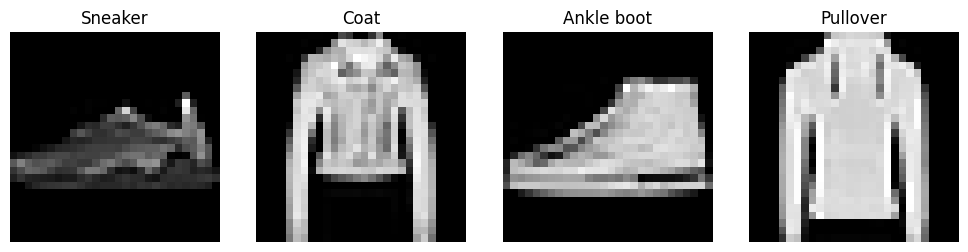

In [ ]:
def show_batch(loader, n=16):
    images, labels = next(iter(loader))
    n = min(n, len(images))
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 2.5 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(class_names[labels[i].item()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=4)

### Preguntas de discusión

1. ¿Qué clases parecen más fáciles de reconocer visualmente?
2. ¿Qué clases podrían confundirse entre sí?
3. ¿Qué diferencia habría entre clasificar estas imágenes y clasificar imágenes reales en color?

## 3. Funciones reutilizables para entrenamiento, evaluación e inferencia

Crearemos funciones generales para no repetir código. Esto nos permitirá entrenar varios modelos y comparar resultados.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}'
        )

    return history


def plot_history(history, title='Training history'):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history['train_loss'], marker='o', label='Train loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title + ' - Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history['train_acc'], marker='o', label='Train accuracy')
    plt.plot(epochs, history['val_acc'], marker='o', label='Validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title + ' - Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

## 4. Baseline: MLP

Antes de usar una CNN, entrenaremos un MLP. Este modelo aplana la imagen de 28×28 y pierde la estructura espacial.

Arquitectura:

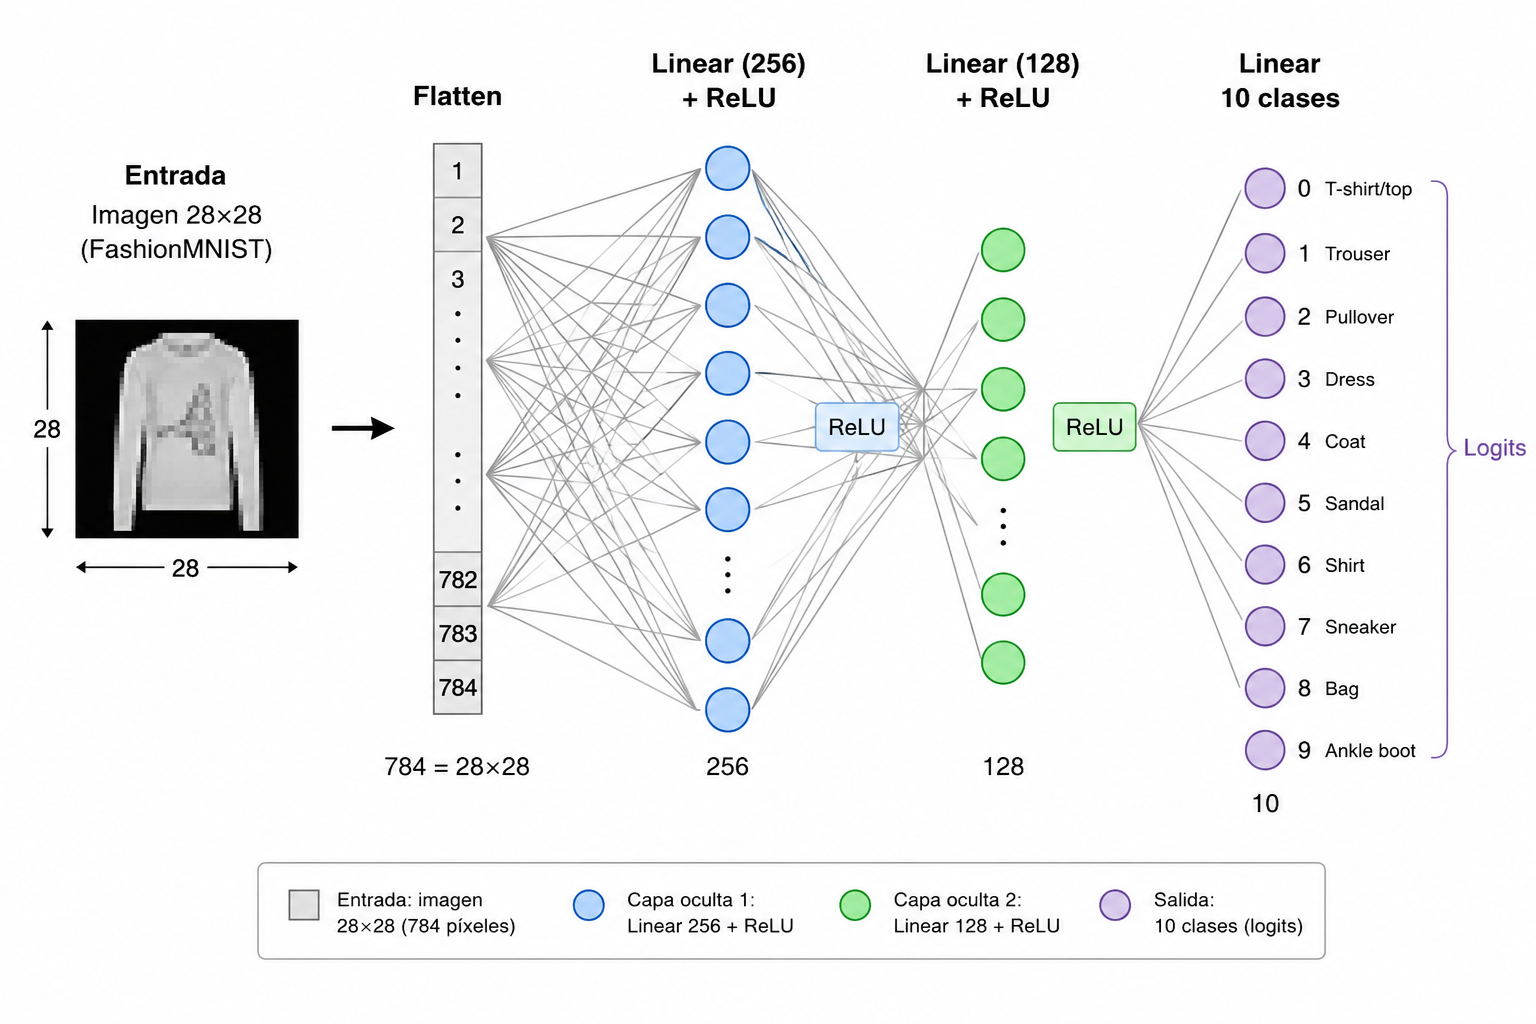

In [ ]:
class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

if TORCHINFO_AVAILABLE:
    summary(mlp, input_size=(batch_size, 1, 28, 28))
else:
    print(mlp)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


Epoch 01/5 | Train Loss: 0.5478 | Train Acc: 0.8040 | Val Loss: 0.4494 | Val Acc: 0.8384
Epoch 02/5 | Train Loss: 0.3830 | Train Acc: 0.8608 | Val Loss: 0.3881 | Val Acc: 0.8566
Epoch 03/5 | Train Loss: 0.3383 | Train Acc: 0.8758 | Val Loss: 0.3598 | Val Acc: 0.8660
Epoch 04/5 | Train Loss: 0.3128 | Train Acc: 0.8845 | Val Loss: 0.3327 | Val Acc: 0.8806
Epoch 05/5 | Train Loss: 0.2927 | Train Acc: 0.8918 | Val Loss: 0.3277 | Val Acc: 0.8816


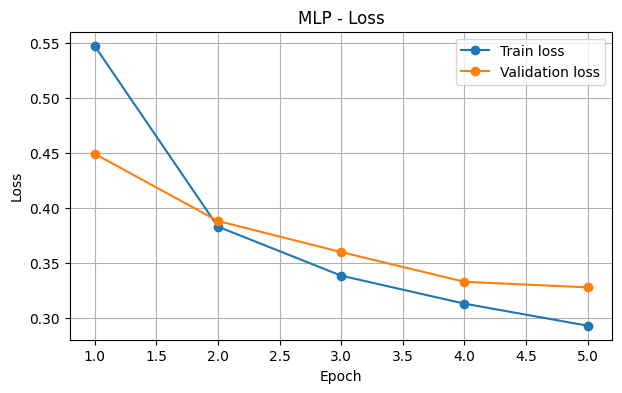

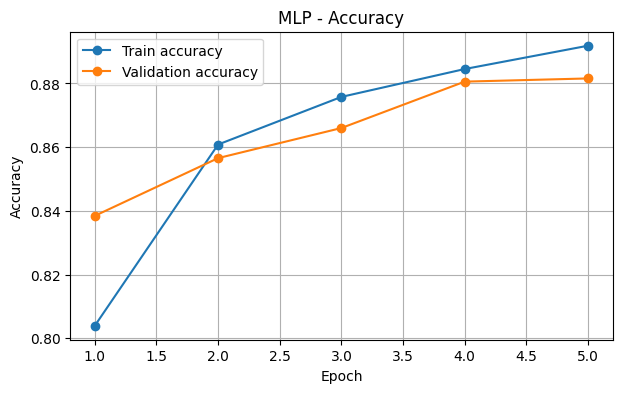

In [ ]:
mlp_history = fit(
    mlp, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=5
)

plot_history(mlp_history, title='MLP')

## 5. Primera CNN para Fashion-MNIST

Ahora entrenaremos una CNN simple.

Arquitectura:

```text
Imagen 1×28×28
↓
Conv2d(1, 16, 3×3, padding=1) + ReLU
↓
MaxPool2d(2×2)
↓
Conv2d(16, 32, 3×3, padding=1) + ReLU
↓
MaxPool2d(2×2)
↓
Flatten
↓
Linear
↓
10 clases
```

Observa que el tamaño espacial cambia así:

```text
28×28 → 14×14 → 7×7
```

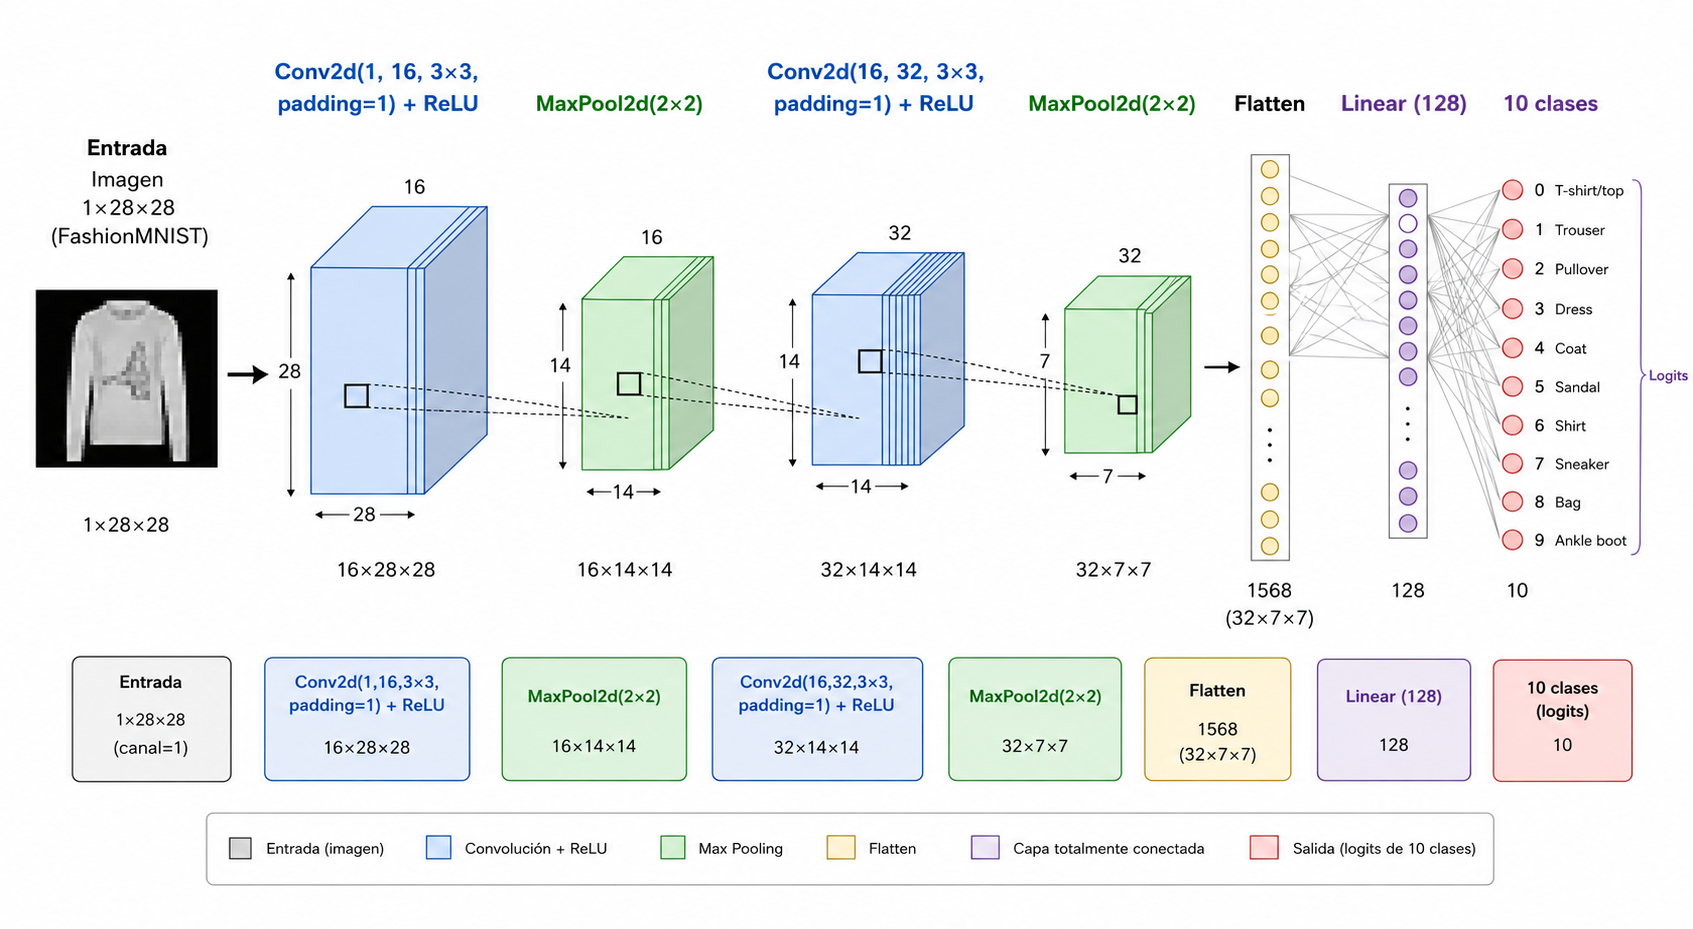

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN().to(device)
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

if TORCHINFO_AVAILABLE:
    summary(cnn, input_size=(batch_size, 1, 28, 28))
else:
    print(cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


Epoch 01/5 | Train Loss: 0.5327 | Train Acc: 0.8057 | Val Loss: 0.3616 | Val Acc: 0.8692
Epoch 02/5 | Train Loss: 0.3334 | Train Acc: 0.8802 | Val Loss: 0.3248 | Val Acc: 0.8847
Epoch 03/5 | Train Loss: 0.2909 | Train Acc: 0.8936 | Val Loss: 0.2984 | Val Acc: 0.8920
Epoch 04/5 | Train Loss: 0.2621 | Train Acc: 0.9022 | Val Loss: 0.2772 | Val Acc: 0.8967
Epoch 05/5 | Train Loss: 0.2403 | Train Acc: 0.9116 | Val Loss: 0.2689 | Val Acc: 0.9000


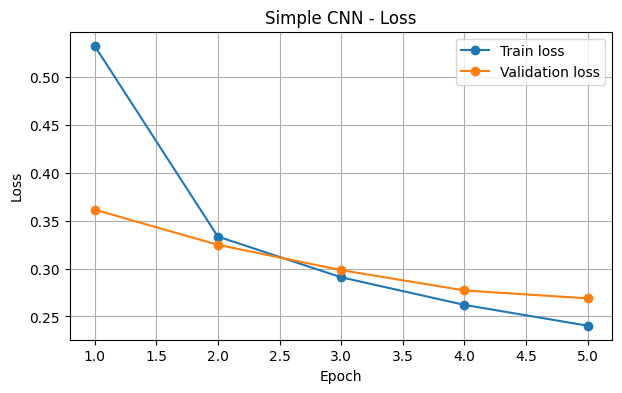

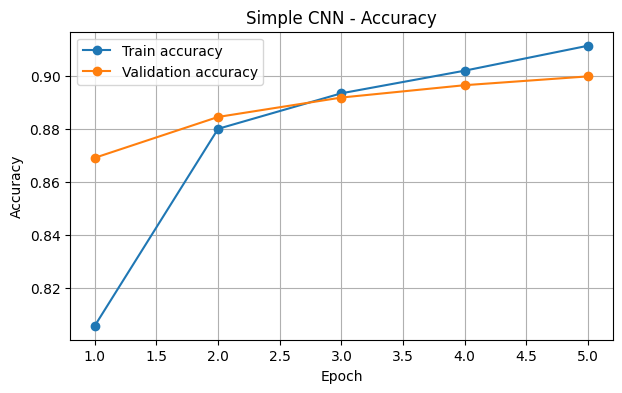

In [ ]:
cnn_history = fit(
    cnn, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=5
)

plot_history(cnn_history, title='Simple CNN')

## 6. Comparación MLP vs CNN

Ahora comparamos ambos modelos en el conjunto de prueba.

In [ ]:
mlp_test_loss, mlp_test_acc, mlp_preds, test_labels = evaluate(mlp, test_loader, criterion, device)
cnn_test_loss, cnn_test_acc, cnn_preds, test_labels = evaluate(cnn, test_loader, criterion, device)

results = pd.DataFrame({
    'Modelo': ['MLP', 'Simple CNN'],
    'Test Loss': [mlp_test_loss, cnn_test_loss],
    'Test Accuracy': [mlp_test_acc, cnn_test_acc]
})

results

,Modelo,Test Loss,Test Accuracy
0,MLP,0.347666,0.8749
1,Simple CNN,0.281243,0.8962


### Preguntas:

1. ¿Cuál modelo obtiene mejor accuracy?
2. ¿Cuál aprovecha mejor la estructura espacial de la imagen?
3. ¿Qué modelo tiene más parámetros?
4. ¿La diferencia de accuracy justifica usar CNN?

## 7. Inferencia con el modelo CNN

Haremos inferencia sobre imágenes individuales. El modelo produce logits, luego usamos softmax para convertirlos en probabilidades.

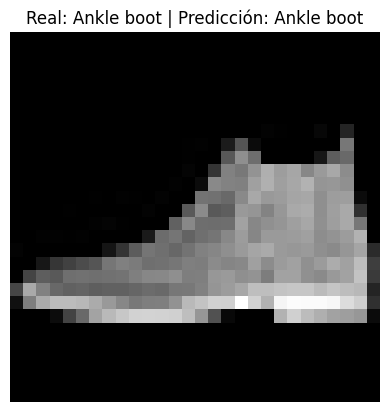

,Clase,Probabilidad
9,Ankle boot,9.985411e-01
7,Sneaker,1.033615e-03
5,Sandal,4.056921e-04
8,Bag,1.417159e-05
0,T-shirt/top,3.920146e-06
6,Shirt,6.368267e-07
3,Dress,3.430511e-07
1,Trouser,3.229990e-07
2,Pullover,2.161464e-07
4,Coat,6.769855e-09


In [ ]:
def predict_image(model, image, device):
    model.eval()
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
    return pred, probs.squeeze().cpu().numpy()

idx = 0
image, label = test_dataset[idx]
pred, probs = predict_image(cnn, image, device)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Real: {class_names[label]} | Predicción: {class_names[pred]}')
plt.axis('off')
plt.show()

pd.DataFrame({
    'Clase': class_names,
    'Probabilidad': probs
}).sort_values('Probabilidad', ascending=False)

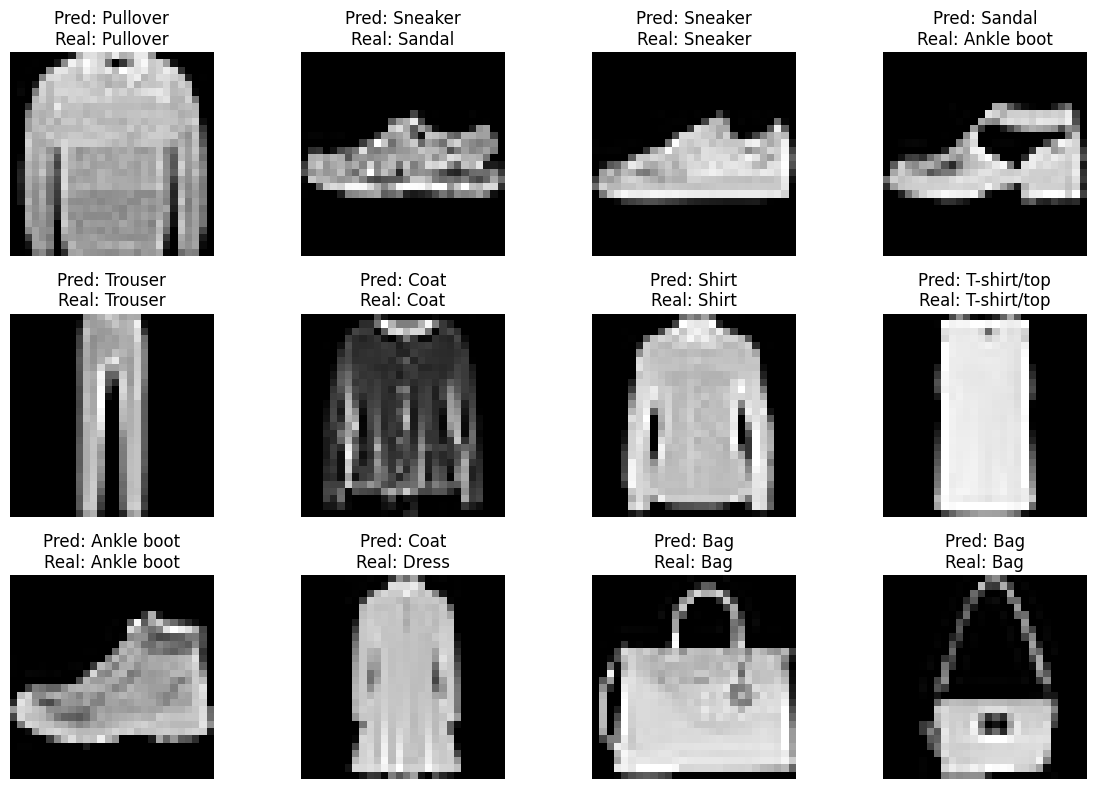

In [ ]:
def show_predictions(model, dataset, n=12, start=0):
    plt.figure(figsize=(12, 8))
    for i in range(n):
        image, label = dataset[start + i]
        pred, probs = predict_image(model, image, device)
        plt.subplot(3, 4, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Pred: {class_names[pred]}\nReal: {class_names[label]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(cnn, test_dataset, n=12, start=20)

## 8. Matriz de confusión y análisis de errores

La accuracy global puede ocultar problemas específicos. Por eso usaremos la matriz de confusión.

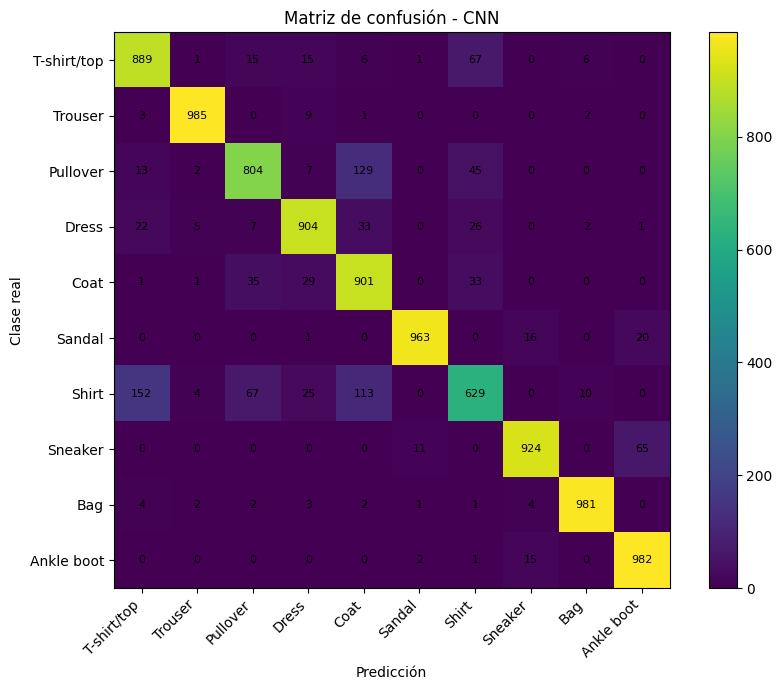

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.89      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.86      0.80      0.83      1000
       Dress       0.91      0.90      0.91      1000
        Coat       0.76      0.90      0.82      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.78      0.63      0.70      1000
     Sneaker       0.96      0.92      0.94      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.92      0.98      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.89     10000
weighted avg       0.90      0.90      0.89     10000



In [ ]:
cm = confusion_matrix(test_labels, cnn_preds)

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de confusión - CNN')
plt.colorbar()
plt.xticks(np.arange(10), class_names, rotation=45, ha='right')
plt.yticks(np.arange(10), class_names)
plt.xlabel('Predicción')
plt.ylabel('Clase real')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(classification_report(test_labels, cnn_preds, target_names=class_names))

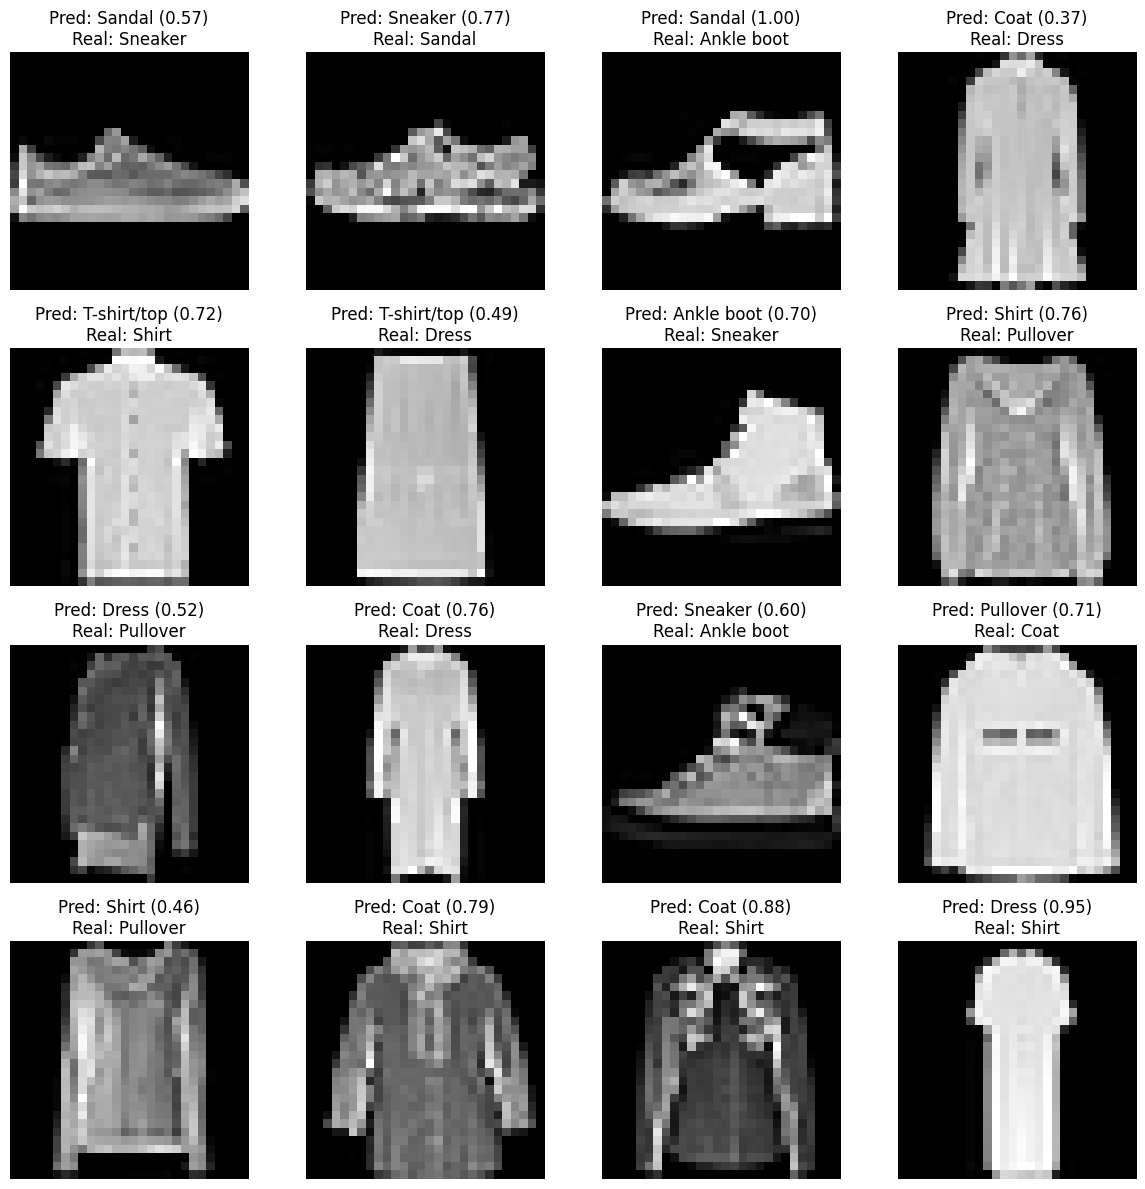

In [ ]:
def show_misclassified(model, dataset, max_images=16):
    model.eval()
    misclassified = []

    for idx in range(len(dataset)):
        image, label = dataset[idx]
        pred, probs = predict_image(model, image, device)
        if pred != label:
            confidence = probs[pred]
            misclassified.append((idx, image, label, pred, confidence))
        if len(misclassified) >= max_images:
            break

    cols = 4
    rows = int(np.ceil(len(misclassified) / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i, (_, image, label, pred, conf) in enumerate(misclassified):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Pred: {class_names[pred]} ({conf:.2f})\nReal: {class_names[label]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_misclassified(cnn, test_dataset, max_images=16)

### Preguntas

1. ¿Qué clases se confunden más?
2. ¿Qué imágenes parecen ambiguas?
3. ¿La matriz de confusión revela un sesgo hacia alguna clase?

## 9. Visualización de filtros aprendidos

Los filtros de la primera capa convolucional tienen forma:

```text
out_channels × in_channels × kernel_height × kernel_width
```

En nuestra CNN:

```text
16 × 1 × 3 × 3
```

Cada filtro aprende un patrón simple, como bordes o contrastes locales.

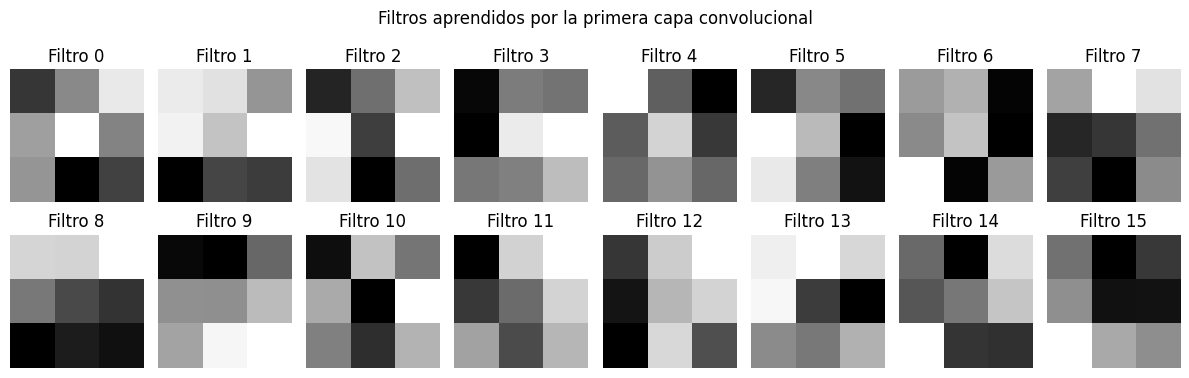

In [ ]:
def visualize_first_layer_filters(model):
    first_conv = None
    for layer in model.modules():
        if isinstance(layer, nn.Conv2d):
            first_conv = layer
            break

    if first_conv is None:
        print('No se encontró ninguna capa Conv2d.')
        return

    filters = first_conv.weight.detach().cpu()
    n_filters = filters.shape[0]

    cols = 8
    rows = int(np.ceil(n_filters / cols))
    plt.figure(figsize=(12, 2 * rows))

    for i in range(n_filters):
        f = filters[i, 0]
        f_min, f_max = f.min(), f.max()
        f_norm = (f - f_min) / (f_max - f_min + 1e-8)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(f_norm, cmap='gray')
        plt.title(f'Filtro {i}')
        plt.axis('off')

    plt.suptitle('Filtros aprendidos por la primera capa convolucional')
    plt.tight_layout()
    plt.show()

visualize_first_layer_filters(cnn)

## 10. Visualización de feature maps

Los feature maps muestran cómo responde cada filtro ante una imagen específica.

Una imagen pasa por la primera capa convolucional y produce varios mapas de activación. Cada mapa resalta regiones donde cierto patrón fue detectado.

In [ ]:
cnn.features

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

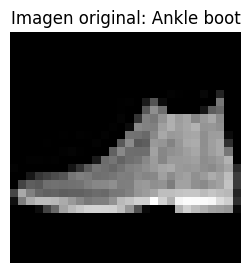

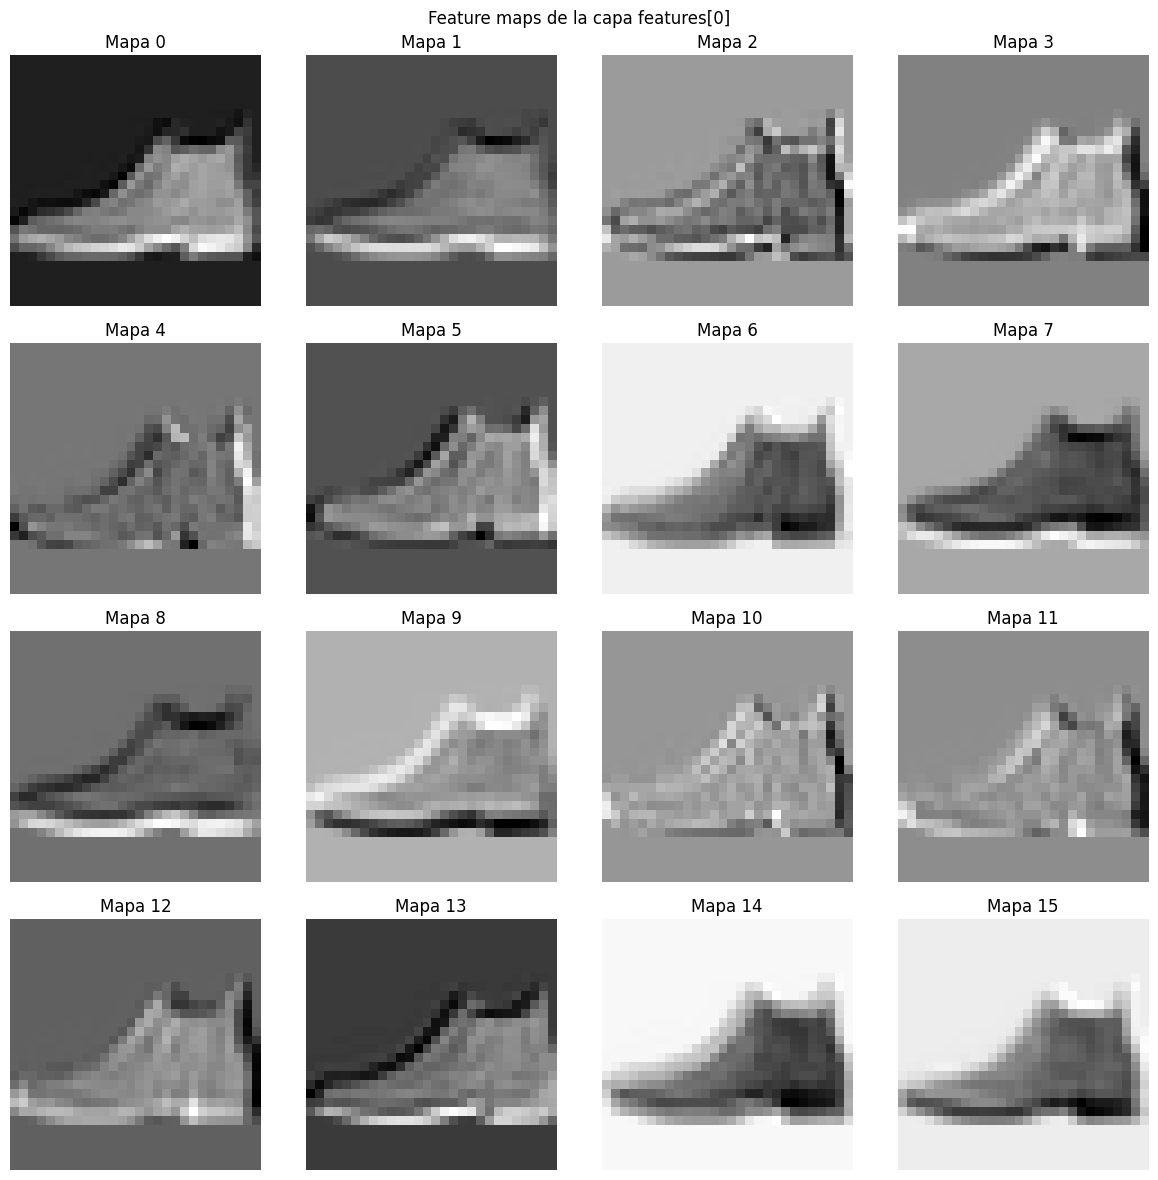

In [ ]:
def get_activations(model, image, layer_index=0):
    """
    Captura la salida de una capa dentro de model.features.
    layer_index se refiere al índice dentro de model.features.
    """
    activations = {}

    def hook_fn(module, input, output):
        activations['value'] = output.detach().cpu()

    layer = model.features[layer_index]
    handle = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))

    handle.remove()
    return activations['value'].squeeze(0)


def visualize_feature_maps(model, dataset, idx=0, layer_index=0, max_maps=16):
    image, label = dataset[idx]
    feature_maps = get_activations(model, image, layer_index=layer_index)
    n_maps = min(max_maps, feature_maps.shape[0])

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Imagen original: {class_names[label]}')
    plt.axis('off')
    plt.show()

    cols = 4
    rows = int(np.ceil(n_maps / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n_maps):
        fmap = feature_maps[i]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(fmap, cmap='gray')
        plt.title(f'Mapa {i}')
        plt.axis('off')
    plt.suptitle(f'Feature maps de la capa features[{layer_index}]')
    plt.tight_layout()
    plt.show()

# features[0] es la primera Conv2d.
visualize_feature_maps(cnn, test_dataset, idx=0, layer_index=0, max_maps=16)

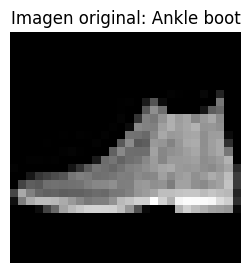

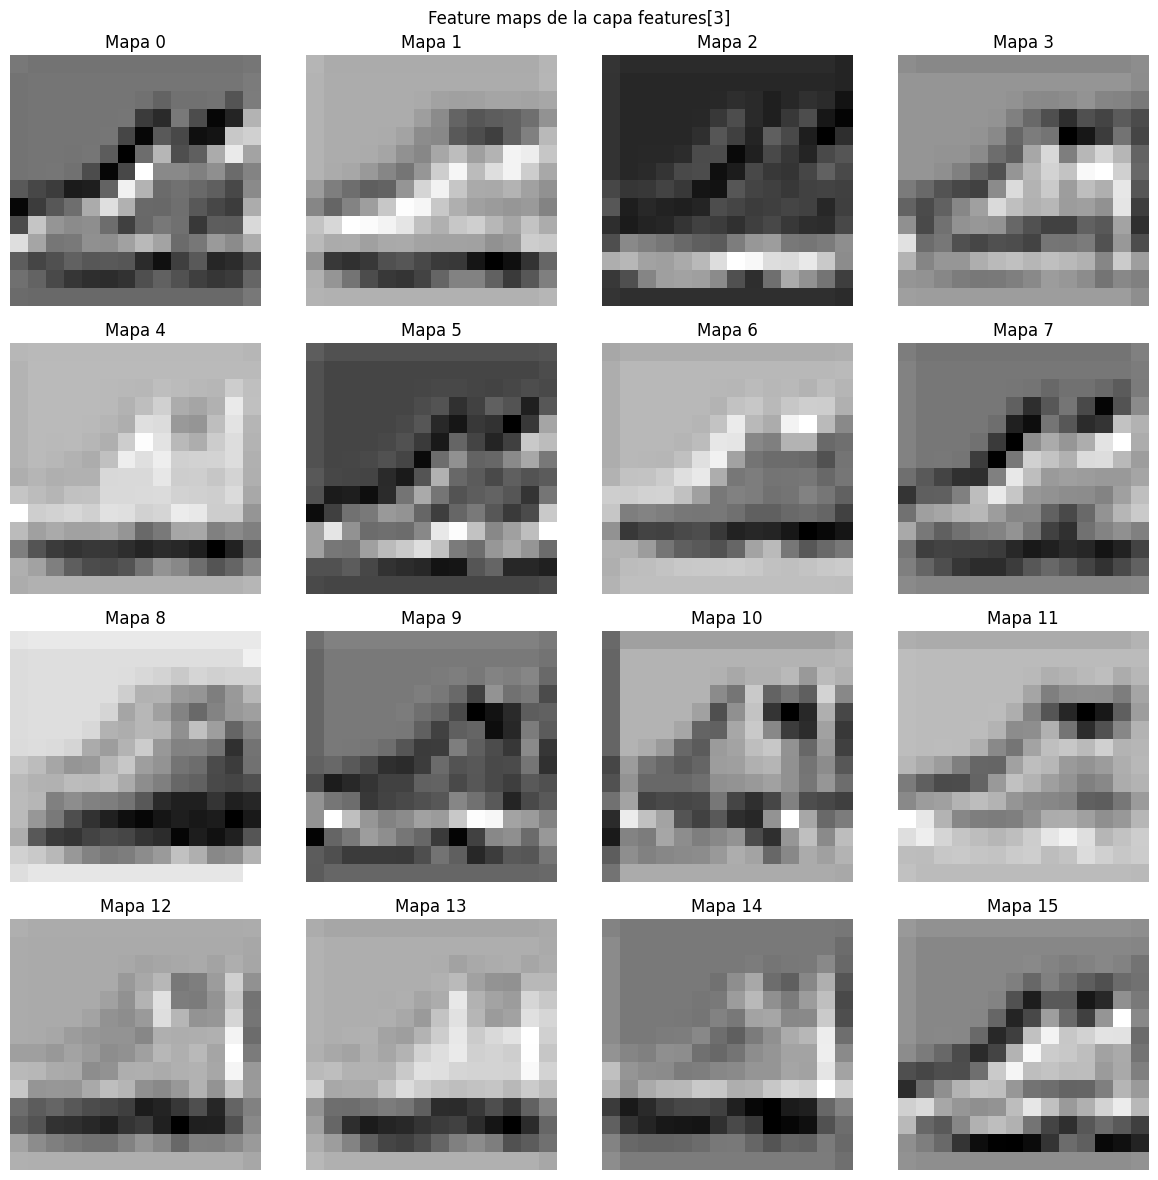

In [ ]:
# Visualizar feature maps después de la segunda convolución.
# En SimpleCNN: features[3] es la segunda Conv2d.
visualize_feature_maps(cnn, test_dataset, idx=0, layer_index=3, max_maps=16)

### Preguntas

1. ¿Qué regiones de la imagen se activan más?
2. ¿Las primeras capas detectan patrones simples o complejos?
3. ¿Los feature maps de capas más profundas son más abstractos?

## 11. Overfitting con un dataset pequeño

Para observar overfitting, reduciremos artificialmente el dataset de entrenamiento y usaremos una CNN más grande. Esto simula una situación común: pocos datos y un modelo con demasiada capacidad.

In [ ]:
small_indices = list(range(2000))
small_train_dataset = Subset(full_train_dataset, small_indices)
small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)

print('Tamaño reducido de entrenamiento:', len(small_train_dataset))

Tamaño reducido de entrenamiento: 2000


In [ ]:
class BigCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

big_cnn = BigCNN(dropout=0.0).to(device)
optimizer = optim.Adam(big_cnn.parameters(), lr=1e-3)

if TORCHINFO_AVAILABLE:
    summary(big_cnn, input_size=(batch_size, 1, 28, 28))
else:
    print(big_cnn)

BigCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Epoch 01/10 | Train Loss: 1.4661 | Train Acc: 0.4455 | Val Loss: 0.8867 | Val Acc: 0.6807
Epoch 02/10 | Train Loss: 0.8474 | Train Acc: 0.6985 | Val Loss: 0.8897 | Val Acc: 0.6810
Epoch 03/10 | Train Loss: 0.6767 | Train Acc: 0.7415 | Val Loss: 0.6810 | Val Acc: 0.7348
Epoch 04/10 | Train Loss: 0.5319 | Train Acc: 0.8040 | Val Loss: 0.5854 | Val Acc: 0.7918
Epoch 05/10 | Train Loss: 0.5091 | Train Acc: 0.8120 | Val Loss: 0.5468 | Val Acc: 0.8063
Epoch 06/10 | Train Loss: 0.4263 | Train Acc: 0.8440 | Val Loss: 0.5255 | Val Acc: 0.8048
Epoch 07/10 | Train Loss: 0.3666 | Train Acc: 0.8700 | Val Loss: 0.4787 | Val Acc: 0.8309
Epoch 08/10 | Train Loss: 0.3340 | Train Acc: 0.8815 | Val Loss: 0.5118 | Val Acc: 0.8166
Epoch 09/10 | Train Loss: 0.2979 | Train Acc: 0.8895 | Val Loss: 0.5551 | Val Acc: 0.8178
Epoch 10/10 | Train Loss: 0.3011 | Train Acc: 0.8820 | Val Loss: 0.5203 | Val Acc: 0.8193


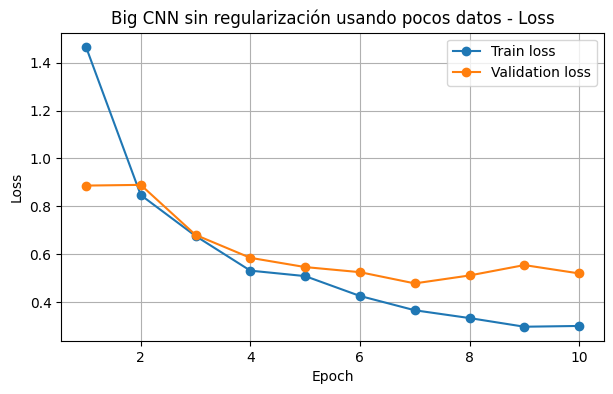

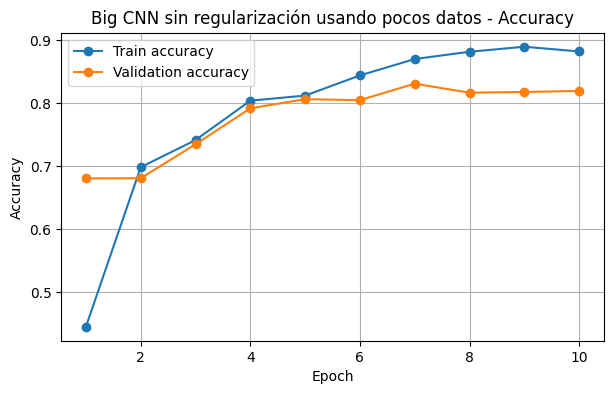

In [ ]:
big_cnn_history = fit(
    big_cnn, small_train_loader, val_loader,
    criterion, optimizer, device,
    epochs=10
)

plot_history(big_cnn_history, title='Big CNN sin regularización usando pocos datos')

### ¿Cómo identificar overfitting?

Hay evidencia de overfitting cuando:

- El **training loss** sigue bajando.
- El **validation loss** deja de bajar o empieza a subir.
- La **training accuracy** aumenta mucho.
- La **validation accuracy** se estanca o disminuye.

### Preguntas

1. ¿En qué época empieza a notarse el overfitting?
2. ¿Por qué el modelo memoriza mejor el dataset pequeño?
3. ¿Qué estrategias podrían reducir este problema?

## 12. Regularización: Dropout y Weight Decay

Usaremos dos técnicas básicas:

1. **Dropout**: apaga aleatoriamente algunas neuronas durante entrenamiento.
2. **Weight Decay**: penaliza pesos demasiado grandes.

Epoch 01/10 | Train Loss: 1.5628 | Train Acc: 0.4225 | Val Loss: 0.9409 | Val Acc: 0.6444
Epoch 02/10 | Train Loss: 0.8911 | Train Acc: 0.6590 | Val Loss: 0.7629 | Val Acc: 0.7048
Epoch 03/10 | Train Loss: 0.7528 | Train Acc: 0.7350 | Val Loss: 0.6427 | Val Acc: 0.7703
Epoch 04/10 | Train Loss: 0.6207 | Train Acc: 0.7780 | Val Loss: 0.6004 | Val Acc: 0.7713
Epoch 05/10 | Train Loss: 0.5325 | Train Acc: 0.8025 | Val Loss: 0.5293 | Val Acc: 0.8020
Epoch 06/10 | Train Loss: 0.4926 | Train Acc: 0.8200 | Val Loss: 0.5259 | Val Acc: 0.8064
Epoch 07/10 | Train Loss: 0.4467 | Train Acc: 0.8320 | Val Loss: 0.5006 | Val Acc: 0.8237
Epoch 08/10 | Train Loss: 0.4178 | Train Acc: 0.8440 | Val Loss: 0.5068 | Val Acc: 0.8190
Epoch 09/10 | Train Loss: 0.3901 | Train Acc: 0.8630 | Val Loss: 0.4727 | Val Acc: 0.8324
Epoch 10/10 | Train Loss: 0.3479 | Train Acc: 0.8680 | Val Loss: 0.4817 | Val Acc: 0.8382


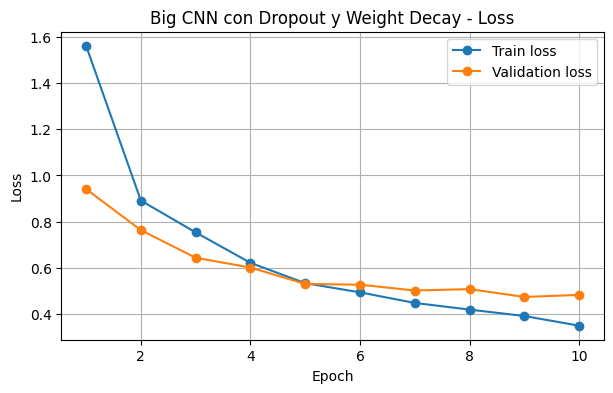

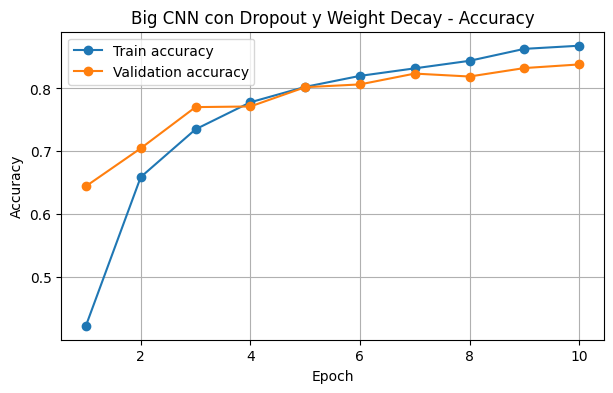

In [ ]:
regularized_cnn = BigCNN(dropout=0.5).to(device)
optimizer = optim.Adam(regularized_cnn.parameters(), lr=1e-3, weight_decay=1e-4)

regularized_history = fit(
    regularized_cnn, small_train_loader, val_loader,
    criterion, optimizer, device,
    epochs=10
)

plot_history(regularized_history, title='Big CNN con Dropout y Weight Decay')

In [ ]:
# Comparación final sobre validación
comparison = pd.DataFrame({
    'Modelo': ['Big CNN sin regularización', 'Big CNN regularizada'],
    'Último Train Acc': [big_cnn_history['train_acc'][-1], regularized_history['train_acc'][-1]],
    'Último Val Acc': [big_cnn_history['val_acc'][-1], regularized_history['val_acc'][-1]],
    'Último Train Loss': [big_cnn_history['train_loss'][-1], regularized_history['train_loss'][-1]],
    'Último Val Loss': [big_cnn_history['val_loss'][-1], regularized_history['val_loss'][-1]],
})

comparison

,Modelo,Último Train Acc,Último Val Acc,Último Train Loss,Último Val Loss
0,Big CNN sin regularización,0.882,0.819333,0.301147,0.520298
1,Big CNN regularizada,0.868,0.838222,0.347926,0.481728


### Preguntas

1. ¿La regularización redujo el gap entre entrenamiento y validación?
2. ¿Dropout siempre mejora la accuracy?
3. ¿Qué pasaría si usamos un Dropout demasiado alto, por ejemplo 0.8?
4. ¿Qué diferencia conceptual hay entre Dropout y Weight Decay?

## 13. Data augmentation básico

Data augmentation crea variaciones aleatorias de las imágenes de entrenamiento. Esto ayuda a que el modelo no memorice exactamente las mismas imágenes.

Para Fashion-MNIST usaremos transformaciones moderadas:

- Rotación pequeña.
- Traslación pequeña.
- Escalamiento suave.

> Cuidado: no toda transformación es válida. Por ejemplo, voltear horizontalmente algunas prendas puede ser razonable, pero en otros dominios, como dígitos o señales, puede cambiar el significado.

In [ ]:
augmented_transform = transforms.Compose([
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ToTensor()
])

augmented_full_train = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=augmented_transform
)

# Usamos los mismos índices pequeños para comparar justamente.
augmented_small_train_dataset = Subset(augmented_full_train, small_indices)
augmented_small_train_loader = DataLoader(augmented_small_train_dataset, batch_size=64, shuffle=True)

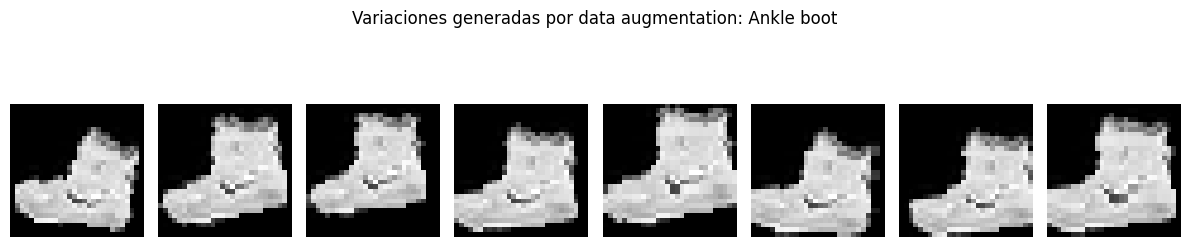

In [ ]:
# Visualizar augmentations de una misma imagen.
base_img, base_label = full_train_dataset[0]

plt.figure(figsize=(12, 3))
for i in range(8):
    aug_img, _ = augmented_full_train[0]
    plt.subplot(1, 8, i + 1)
    plt.imshow(aug_img.squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle(f'Variaciones generadas por data augmentation: {class_names[base_label]}')
plt.tight_layout()
plt.show()

Epoch 01/10 | Train Loss: 1.6686 | Train Acc: 0.3730 | Val Loss: 0.9715 | Val Acc: 0.6244
Epoch 02/10 | Train Loss: 1.0733 | Train Acc: 0.5800 | Val Loss: 0.8501 | Val Acc: 0.6626
Epoch 03/10 | Train Loss: 0.9129 | Train Acc: 0.6655 | Val Loss: 0.7054 | Val Acc: 0.7336
Epoch 04/10 | Train Loss: 0.7848 | Train Acc: 0.6950 | Val Loss: 0.6795 | Val Acc: 0.7380
Epoch 05/10 | Train Loss: 0.7537 | Train Acc: 0.7195 | Val Loss: 0.6813 | Val Acc: 0.7328
Epoch 06/10 | Train Loss: 0.7097 | Train Acc: 0.7385 | Val Loss: 0.6012 | Val Acc: 0.7636
Epoch 07/10 | Train Loss: 0.6873 | Train Acc: 0.7370 | Val Loss: 0.5946 | Val Acc: 0.7667
Epoch 08/10 | Train Loss: 0.6825 | Train Acc: 0.7195 | Val Loss: 0.5734 | Val Acc: 0.7769
Epoch 09/10 | Train Loss: 0.6703 | Train Acc: 0.7520 | Val Loss: 0.5643 | Val Acc: 0.7769
Epoch 10/10 | Train Loss: 0.6146 | Train Acc: 0.7555 | Val Loss: 0.5772 | Val Acc: 0.7751


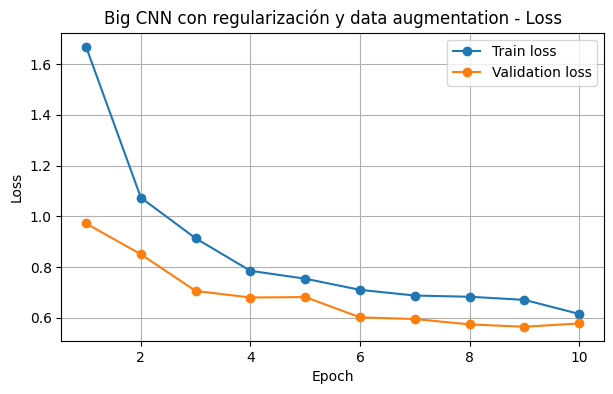

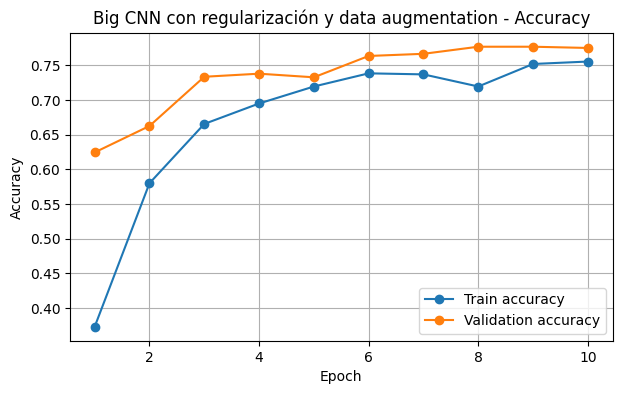

In [ ]:
augmented_cnn = BigCNN(dropout=0.5).to(device)
optimizer = optim.Adam(augmented_cnn.parameters(), lr=1e-3, weight_decay=1e-4)

augmented_history = fit(
    augmented_cnn, augmented_small_train_loader, val_loader,
    criterion, optimizer, device,
    epochs=10
)

plot_history(augmented_history, title='Big CNN con regularización y data augmentation')

### Preguntas

1. ¿Data augmentation mejoró la validación?
2. ¿Aumentó o redujo la dificultad del entrenamiento?
3. ¿Qué transformaciones serían peligrosas para este dataset?
4. ¿Qué transformaciones usarías para imágenes médicas?

## 14. Transfer learning con un modelo preentrenado simple

Fashion-MNIST tiene imágenes en escala de grises de 28×28, mientras que los modelos preentrenados en ImageNet esperan imágenes RGB, usualmente de 224×224.

Para usar transfer learning:

1. Convertiremos la imagen a 3 canales.
2. Redimensionaremos a 224×224.
3. Usaremos un modelo preentrenado simple, como **ResNet18**.
4. Congelaremos sus capas convolucionales.
5. Cambiaremos la última capa para clasificar 10 clases.

> Nota: En Fashion-MNIST, transfer learning puede ser más costoso y no necesariamente mucho mejor que una CNN simple, pero sirve para aprender el pipeline usado en problemas reales.

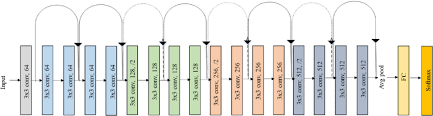

In [ ]:
transfer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transfer_full_train = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transfer_transform
)
transfer_test = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transfer_transform
)

# Para que la sección sea rápida, usamos subsets pequeños.
transfer_train_subset = Subset(transfer_full_train, list(range(2000)))
transfer_val_subset = Subset(transfer_full_train, list(range(2000, 2500)))
transfer_test_subset = Subset(transfer_test, list(range(1000)))

transfer_train_loader = DataLoader(transfer_train_subset, batch_size=32, shuffle=True)
transfer_val_loader = DataLoader(transfer_val_subset, batch_size=32, shuffle=False)
transfer_test_loader = DataLoader(transfer_test_subset, batch_size=32, shuffle=False)

In [ ]:
# Dependiendo de la versión de torchvision, la forma de cargar pesos puede cambiar.
try:
    weights = models.ResNet18_Weights.DEFAULT
    transfer_model = models.resnet18(weights=weights)
except Exception:
    transfer_model = models.resnet18(pretrained=True)

# Congelar capas base.
for param in transfer_model.parameters():
    param.requires_grad = False

# Reemplazar capa final.
in_features = transfer_model.fc.in_features #Imagenet sería in_features x 1000
transfer_model.fc = nn.Linear(in_features, 10)
transfer_model = transfer_model.to(device)

optimizer = optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

if TORCHINFO_AVAILABLE:
    summary(transfer_model, input_size=(32, 3, 224, 224))
else:
    print(transfer_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Epoch 01/3 | Train Loss: 1.5996 | Train Acc: 0.5095 | Val Loss: 1.1746 | Val Acc: 0.6660
Epoch 02/3 | Train Loss: 0.8991 | Train Acc: 0.7595 | Val Loss: 0.7768 | Val Acc: 0.7740
Epoch 03/3 | Train Loss: 0.7284 | Train Acc: 0.7820 | Val Loss: 0.7195 | Val Acc: 0.7620


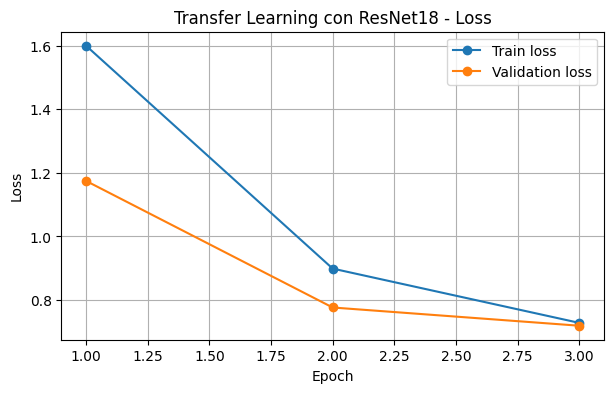

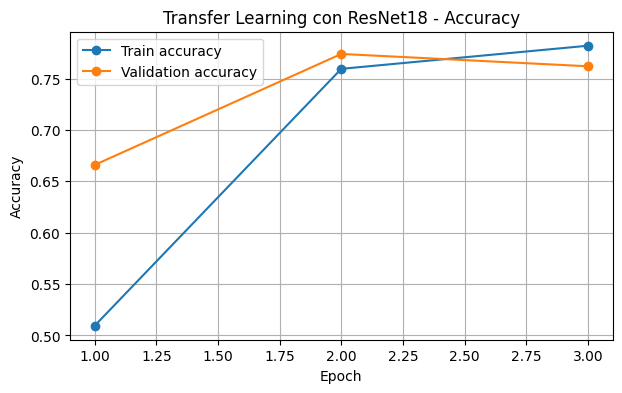

In [ ]:
# Esta sección puede tardar más que las anteriores si no hay GPU.
transfer_history = fit(
    transfer_model, transfer_train_loader, transfer_val_loader,
    criterion, optimizer, device,
    epochs=3
)

plot_history(transfer_history, title='Transfer Learning con ResNet18')

In [ ]:
transfer_test_loss, transfer_test_acc, transfer_preds, transfer_labels = evaluate(
    transfer_model, transfer_test_loader, criterion, device
)
print(f'Transfer learning test accuracy en subset: {transfer_test_acc:.4f}')

Transfer learning test accuracy en subset: 0.7770


### Preguntas de discusión

1. ¿Por qué hay que convertir Fashion-MNIST a 3 canales?
2. ¿Por qué hay que reemplazar la última capa?
3. ¿Qué ventaja tiene congelar las capas iniciales?
4. ¿En qué casos conviene hacer fine-tuning completo?
5. ¿Por qué transfer learning puede ser más útil en datasets pequeños del mundo real que en Fashion-MNIST?

## 15. Robustez ante ruido

Ahora veremos cómo cambia el desempeño de la CNN cuando agregamos ruido a las imágenes.

Evaluaremos con ruido gaussiano:

```text
imagen_ruidosa = imagen + ruido
```

Luego recortamos los valores para que sigan dentro del rango `[0, 1]`.

In [ ]:
def add_gaussian_noise(images, std=0.2):
    noise = torch.randn_like(images) * std
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)


def evaluate_with_noise(model, loader, criterion, device, noise_std=0.2):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            noisy_images = add_gaussian_noise(images, std=noise_std)
            outputs = model(noisy_images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40]
noise_results = []

for std in noise_levels:
    loss, acc = evaluate_with_noise(cnn, test_loader, criterion, device, noise_std=std)
    noise_results.append({'Noise std': std, 'Accuracy': acc, 'Loss': loss})

noise_df = pd.DataFrame(noise_results)
noise_df

,Noise std,Accuracy,Loss
0,0.00,0.8962,0.281243
1,0.05,0.8841,0.315247
2,0.10,0.8294,0.438299
3,0.20,0.5969,1.130490
4,0.30,0.3243,2.512158
5,0.40,0.1780,4.107685


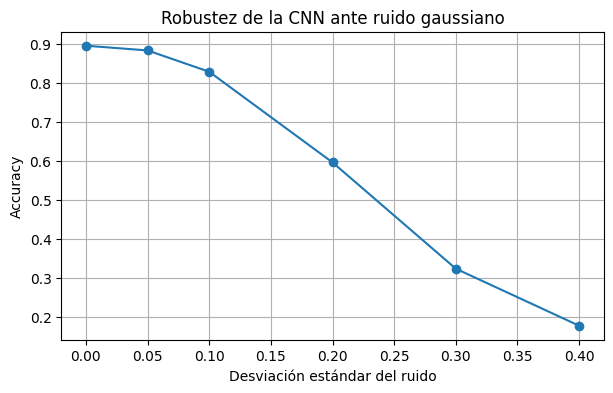

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(noise_df['Noise std'], noise_df['Accuracy'], marker='o')
plt.xlabel('Desviación estándar del ruido')
plt.ylabel('Accuracy')
plt.title('Robustez de la CNN ante ruido gaussiano')
plt.grid(True)
plt.show()

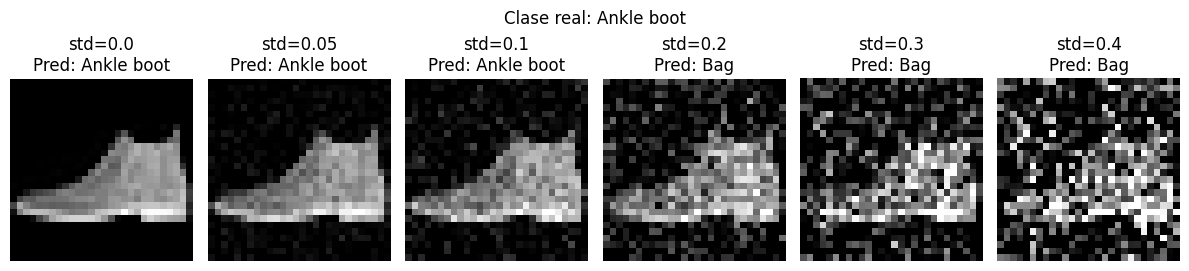

In [ ]:
# Visualizar ejemplos con distintos niveles de ruido.
image, label = test_dataset[0]

plt.figure(figsize=(12, 3))
for i, std in enumerate(noise_levels):
    noisy = add_gaussian_noise(image.unsqueeze(0), std=std).squeeze(0)
    pred, _ = predict_image(cnn, noisy, device)
    plt.subplot(1, len(noise_levels), i + 1)
    plt.imshow(noisy.squeeze(), cmap='gray')
    plt.title(f'std={std}\nPred: {class_names[pred]}')
    plt.axis('off')
plt.suptitle(f'Clase real: {class_names[label]}')
plt.tight_layout()
plt.show()

### Preguntas

1. ¿A partir de qué nivel de ruido cae notablemente la accuracy?
2. ¿El modelo falla de forma gradual o abrupta?
3. ¿Qué clases podrían ser más sensibles al ruido?
4. ¿Cómo podríamos entrenar un modelo más robusto?

## 16. Desafío (con nota)

### Actividad 1: modificar la CNN

Prueba cambiar:

- Número de filtros: 16/32 vs 32/64.
- Kernel size: 3×3 vs 5×5.
- Dropout: 0.0, 0.3, 0.5.
- Learning rate: 1e-2, 1e-3, 1e-4.

Completa una tabla:

| Modelo | Filtros | Dropout | Weight Decay | Accuracy Validación | Accuracy Test |
|---|---:|---:|---:|---:|---:|
| CNN base | 16/32 | 0.0 | 0.0 | | |
| CNN regularizada | 32/64 | 0.5 | 1e-4 | | |

---

### Actividad 2: análisis de errores

Selecciona 10 errores del modelo y clasifícalos como:

- Imagen ambigua.
- Clase visualmente similar.
- Error inesperado.
- Imagen con poca información.

---

### Actividad 3: robustez

Entrena una CNN con data augmentation y compara su accuracy bajo ruido con la CNN base.

Pregunta:

> ¿Data augmentation mejora la robustez ante ruido?

---

### Actividad 4: transfer learning - 1

Descongela el último bloque de ResNet18 y vuelve a entrenar.

Pregunta:

> ¿Mejora la accuracy o aparece overfitting?

### Actividad 5: transfer learning - 2

Compara al menos 2 modelos de la siguiente lista: https://docs.pytorch.org/vision/0.8/models.html

Pregunta:

> ¿Qué modelo produjo los mejores resultados?

## 17. Conclusiones

1. Una CNN aprovecha mejor la estructura espacial que un MLP.
2. El entrenamiento debe evaluarse con curvas de loss y accuracy.
3. La matriz de confusión revela errores específicos por clase.
4. Los filtros aprendidos permiten entender parcialmente qué patrones detecta la red.
5. Los feature maps muestran activaciones intermedias.
6. El overfitting aparece cuando el modelo memoriza el entrenamiento y no generaliza.
7. Dropout, Weight Decay y Data Augmentation pueden reducir overfitting.
8. Transfer learning permite reutilizar modelos preentrenados.
9. La accuracy puede caer con ruido.
10. Los ejemplos adversariales muestran que las CNN pueden ser vulnerables a perturbaciones pequeñas pero dirigidas.



## Desarrollo del Desafío (Actividades 1 a 5)

> **Cómo correr esto:** estas celdas reutilizan todo lo ya definido arriba
> (`fit`, `evaluate`, `evaluate_with_noise`, `add_gaussian_noise`,
> `predict_image`, `plot_history`, `class_names`, los `*_loader`, `criterion`,
> `device`, etc.). Ejecuta primero el notebook de arriba hasta la sección 16.
>
> Se recomienda **GPU** (`Entorno de ejecución > Cambiar tipo de entorno > GPU`).
> En CPU funciona igual, solo que más lento: baja las variables `EPOCHS_*`
> si necesitas que corra rápido.


### Actividad 1 — Modificar la CNN

Definimos una **CNN configurable** (filtros, tamaño de kernel y dropout) y un
ayudante `run_experiment` que entrena, evalúa en validación/test y cuenta
parámetros. Luego barremos varias configuraciones y llenamos la tabla pedida.

El `padding = kernel_size // 2` mantiene el tamaño espacial, así que tras dos
`MaxPool(2)` siempre llegamos a `7x7` (`28 -> 14 -> 7`), sin importar si el
kernel es 3x3 o 5x5.


In [ ]:
class ConfigurableCNN(nn.Module):
    """CNN simple parametrizable para los experimentos de la Actividad 1."""
    def __init__(self, num_classes=10, f1=16, f2=32, kernel_size=3, dropout=0.0):
        super().__init__()
        pad = kernel_size // 2  # mantiene el tamaño espacial -> 28->14->7
        self.features = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(f1, f2, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f2 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def run_experiment(nombre, f1, f2, kernel_size, dropout, weight_decay, lr,
                   epochs=5, tr_loader=train_loader, va_loader=val_loader):
    """Entrena una ConfigurableCNN y devuelve un dict con métricas."""
    set_seed(42)  # mismas condiciones iniciales para comparar de forma justa
    model = ConfigurableCNN(f1=f1, f2=f2, kernel_size=kernel_size, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f"\n=== {nombre} (f={f1}/{f2}, k={kernel_size}, do={dropout}, wd={weight_decay}, lr={lr}) ===")
    hist = fit(model, tr_loader, va_loader, criterion, optimizer, device, epochs=epochs)

    val_acc = hist['val_acc'][-1]
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    return {
        'Modelo': nombre,
        'Filtros': f'{f1}/{f2}',
        'Kernel': f'{kernel_size}x{kernel_size}',
        'Dropout': dropout,
        'Weight Decay': weight_decay,
        'LR': lr,
        'Params': count_params(model),
        'Val Accuracy': round(val_acc, 4),
        'Test Accuracy': round(test_acc, 4),
    }


In [ ]:
# Baja EPOCHS_A1 a 3 si vas en CPU y quieres que corra rápido.
EPOCHS_A1 = 5

configs = [
    # nombre,                 f1, f2, k, dropout, wd,    lr
    ("CNN base",              16, 32, 3, 0.0,     0.0,   1e-3),
    ("CNN regularizada",      32, 64, 3, 0.5,     1e-4,  1e-3),
    ("CNN kernel 5x5",        32, 64, 5, 0.5,     1e-4,  1e-3),
    ("CNN lr alto (1e-2)",    32, 64, 3, 0.5,     1e-4,  1e-2),
    ("CNN lr bajo (1e-4)",    32, 64, 3, 0.5,     1e-4,  1e-4),
]

act1_rows = [run_experiment(n, f1, f2, k, do, wd, lr, epochs=EPOCHS_A1)
             for (n, f1, f2, k, do, wd, lr) in configs]

act1_results = pd.DataFrame(act1_rows)
act1_results


**Cómo interpretar la tabla (Actividad 1)**

- **Filtros 32/64 vs 16/32:** más filtros => más parámetros y normalmente algo
  más de accuracy, pero con rendimientos decrecientes en un dataset tan simple.
- **Kernel 5x5 vs 3x3:** el 5x5 capta contexto más amplio pero tiene más
  parámetros por capa; en Fashion-MNIST la diferencia suele ser pequeña.
- **Dropout + Weight Decay:** reducen el gap train/val (menos overfitting); con
  pocas épocas a veces bajan un poco la accuracy de train pero mejoran la de val.
- **Learning rate:** `1e-2` suele ser inestable (loss que rebota o se estanca),
  `1e-4` converge lento, `1e-3` es el punto dulce con Adam.

> Copia los valores reales de `act1_results` a la tabla del enunciado.
> El modelo con **más parámetros** es el de 32/64 (míralo en la columna `Params`).


### Actividad 2 — Análisis de errores

Recolectamos errores del modelo `cnn`, los mostramos con su confianza y
proponemos una **categoría automática** según el tipo de confusión. Tú revisas
y ajustas la categoría final en la columna `categoria` del DataFrame.

Categorías pedidas:
- **ambigua** — la prenda en sí es difícil de distinguir.
- **similar_visual** — se confunde con una clase parecida (Shirt/T-shirt/Pullover/Coat, o Sandal/Sneaker/Ankle boot).
- **inesperado** — error raro con alta confianza.
- **poca_info** — imagen muy oscura / recortada / con poca señal.


In [ ]:
# Grupos de clases visualmente parecidas en Fashion-MNIST
GRUPOS_SIMILARES = [
    {'T-shirt/top', 'Shirt', 'Pullover', 'Coat', 'Dress'},  # torso
    {'Sandal', 'Sneaker', 'Ankle boot'},                    # calzado
]

def misma_familia(a, b):
    return any({a, b} <= g for g in GRUPOS_SIMILARES)

def sugerir_categoria(real, pred, conf):
    if misma_familia(real, pred):
        return 'similar_visual'
    if conf >= 0.85:
        return 'inesperado'        # se equivoca pero muy seguro
    if conf < 0.45:
        return 'ambigua'           # ni el modelo está seguro
    return 'poca_info'


def recolectar_errores(model, dataset, n=10):
    model.eval()
    filas, imgs = [], []
    for idx in range(len(dataset)):
        image, label = dataset[idx]
        pred, probs = predict_image(model, image, device)
        if pred != label:
            conf = float(probs[pred])
            filas.append({
                'idx': idx,
                'real': class_names[label],
                'pred': class_names[pred],
                'confianza': round(conf, 3),
                'categoria_sugerida': sugerir_categoria(class_names[label], class_names[pred], conf),
                'categoria': '',  # <- completa tú aquí tras revisar la imagen
            })
            imgs.append(image)
        if len(filas) >= n:
            break
    return filas, imgs


filas, imgs = recolectar_errores(cnn, test_dataset, n=10)

# Mostrar los 10 errores
cols = 5
rows = int(np.ceil(len(imgs) / cols))
plt.figure(figsize=(13, 3 * rows))
for i, (f, img) in enumerate(zip(filas, imgs)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"#{f['idx']}\nReal: {f['real']}\nPred: {f['pred']} ({f['confianza']:.2f})",
              fontsize=8)
    plt.axis('off')
plt.suptitle('Actividad 2 - 10 errores del modelo CNN')
plt.tight_layout()
plt.show()

errores_df = pd.DataFrame(filas)
errores_df


**Conclusión típica (Actividad 2)**

La mayoría de errores caen en **similar_visual**: el clásico cruce
**Shirt ↔ T-shirt/top ↔ Pullover ↔ Coat**, porque en 28×28 grises esas
prendas comparten silueta. El calzado casi no se confunde entre sí salvo
**Sandal ↔ Sneaker**. Los errores **inesperado** (alta confianza pero
equivocado) son los más interesantes para reportar, y los **ambigua** suelen
ser imágenes que un humano también dudaría.

> Edita la columna `categoria` de `errores_df` con tu criterio final tras mirar
> cada imagen; la `categoria_sugerida` es solo una ayuda heurística.


### Actividad 3 — Robustez con Data Augmentation

Entrenamos una CNN **con data augmentation** sobre el set completo y comparamos
su accuracy bajo ruido gaussiano contra la `cnn` base (sin augmentation),
reutilizando `evaluate_with_noise` y `noise_levels`.


In [ ]:
# Loader de entrenamiento COMPLETO con augmentation (reusa augmented_transform de la secc. 13)
aug_full_loader = DataLoader(augmented_full_train, batch_size=64, shuffle=True)

EPOCHS_A3 = 5

# CNN con data augmentation (misma arquitectura que la cnn base: SimpleCNN)
set_seed(42)
cnn_aug = SimpleCNN().to(device)
optimizer = optim.Adam(cnn_aug.parameters(), lr=1e-3)
cnn_aug_history = fit(cnn_aug, aug_full_loader, val_loader,
                      criterion, optimizer, device, epochs=EPOCHS_A3)
plot_history(cnn_aug_history, title='CNN con Data Augmentation (set completo)')


In [ ]:
# Comparar robustez ante ruido: CNN base vs CNN con augmentation
rob_rows = []
for std in noise_levels:
    _, acc_base = evaluate_with_noise(cnn,     test_loader, criterion, device, noise_std=std)
    _, acc_aug  = evaluate_with_noise(cnn_aug, test_loader, criterion, device, noise_std=std)
    rob_rows.append({'Noise std': std,
                     'Acc CNN base': round(acc_base, 4),
                     'Acc CNN + augment': round(acc_aug, 4)})

robustez_df = pd.DataFrame(rob_rows)
print(robustez_df)

plt.figure(figsize=(7, 4))
plt.plot(robustez_df['Noise std'], robustez_df['Acc CNN base'], marker='o', label='CNN base')
plt.plot(robustez_df['Noise std'], robustez_df['Acc CNN + augment'], marker='o', label='CNN + augment')
plt.xlabel('Desviación estándar del ruido')
plt.ylabel('Accuracy')
plt.title('Actividad 3 - Robustez ante ruido: base vs data augmentation')
plt.legend()
plt.grid(True)
plt.show()


**¿Data augmentation mejora la robustez ante ruido?**

En general **sí, parcialmente**: el augmentation (rotaciones, traslaciones,
escalas) obliga al modelo a no memorizar píxeles exactos, así que tolera mejor
las perturbaciones. La curva de `CNN + augment` suele caer **más despacio** a
medida que sube el ruido. Ojo: el augmentation usado aquí **no incluye ruido**,
así que la mejora ante ruido gaussiano es un efecto secundario; si quisieras
robustez específica a ruido, lo ideal es **agregar ruido durante el
entrenamiento** (noise injection). Confirma la conclusión con tu `robustez_df`.


### Actividad 4 — Transfer Learning: descongelar el último bloque

Tomamos ResNet18 preentrenada, congelamos todo, reemplazamos la capa final y
**descongelamos `layer4`** (el último bloque convolucional). Entrenamos `layer4`
+ `fc` y comparamos contra la versión totalmente congelada de la sección 14.

> Requiere haber corrido las celdas de la sección 14 (`transfer_*_loader`,
> `transfer_history`, `transfer_test_acc`).


In [ ]:
EPOCHS_A4 = 3

# Reconstruir ResNet18 y descongelar layer4 + fc
try:
    weights = models.ResNet18_Weights.DEFAULT
    ft_model = models.resnet18(weights=weights)
except Exception:
    ft_model = models.resnet18(pretrained=True)

for param in ft_model.parameters():
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, 10)
for param in ft_model.layer4.parameters():   # descongelar último bloque
    param.requires_grad = True

ft_model = ft_model.to(device)

# El optimizador solo recibe los parámetros entrenables (layer4 + fc)
trainable_params = [p for p in ft_model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4)  # lr más bajo al hacer fine-tuning

ft_history = fit(ft_model, transfer_train_loader, transfer_val_loader,
                 criterion, optimizer, device, epochs=EPOCHS_A4)
plot_history(ft_history, title='ResNet18 con layer4 descongelado (fine-tuning)')

ft_test_loss, ft_test_acc, _, _ = evaluate(ft_model, transfer_test_loader, criterion, device)
print(f'\nFrozen (solo fc)         test acc: {transfer_test_acc:.4f}')
print(f'Fine-tuning (layer4+fc)  test acc: {ft_test_acc:.4f}')


**¿Mejora la accuracy o aparece overfitting?**

Descongelar `layer4` deja que las características de alto nivel se adapten a
Fashion-MNIST, así que normalmente **sube la accuracy de test** respecto a
entrenar solo `fc`. El riesgo es overfitting: si en `ft_history` ves que el
`train_acc` se dispara mientras el `val_acc` se estanca o baja, ya estás
memorizando — por eso usamos un **learning rate más bajo (1e-4)** y pocas
épocas. Compara `ft_test_acc` vs `transfer_test_acc` y mira el gap train/val.


### Actividad 5 — Transfer Learning: comparar 2+ modelos

Comparamos **ResNet18** vs **MobileNetV2** (puedes añadir más de la lista). Una
función genérica reemplaza la cabeza de cada arquitectura, congela la base,
entrena solo la cabeza y evalúa en el mismo subset de test.


In [ ]:
def build_transfer_model(name, num_classes=10):
    """Carga un modelo preentrenado, congela la base y reemplaza su cabeza."""
    ctor = getattr(models, name)
    try:
        model = ctor(weights='DEFAULT')
    except Exception:
        model = ctor(pretrained=True)

    for p in model.parameters():
        p.requires_grad = False

    # Reemplazo de cabeza segun arquitectura
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):            # resnet, googlenet
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head = model.fc
    elif hasattr(model, 'classifier'):
        clf = model.classifier
        if isinstance(clf, nn.Linear):                                      # densenet
            model.classifier = nn.Linear(clf.in_features, num_classes)
            head = model.classifier
        elif isinstance(clf[-1], nn.Linear):                                # mobilenet, vgg, efficientnet
            clf[-1] = nn.Linear(clf[-1].in_features, num_classes)
            head = clf[-1]
        elif isinstance(clf[1], nn.Conv2d):                                 # squeezenet
            clf[1] = nn.Conv2d(clf[1].in_channels, num_classes, kernel_size=1)
            head = clf[1]
    return model, head


def entrenar_transfer(name, epochs=3, lr=1e-3):
    set_seed(42)
    model, head = build_transfer_model(name)
    model = model.to(device)
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    print(f"\n=== Transfer learning: {name} ===")
    hist = fit(model, transfer_train_loader, transfer_val_loader,
               criterion, optimizer, device, epochs=epochs)
    test_loss, test_acc, _, _ = evaluate(model, transfer_test_loader, criterion, device)
    return {'Modelo': name,
            'Val Acc': round(hist['val_acc'][-1], 4),
            'Test Acc': round(test_acc, 4),
            'Params entrenables': sum(p.numel() for p in model.parameters() if p.requires_grad)}


In [ ]:
EPOCHS_A5 = 3

# Puedes agregar 'resnet34', 'squeezenet1_0', 'densenet121', etc.
modelos_a_comparar = ['resnet18', 'mobilenet_v2']

act5_rows = [entrenar_transfer(name, epochs=EPOCHS_A5) for name in modelos_a_comparar]
act5_results = pd.DataFrame(act5_rows).sort_values('Test Acc', ascending=False)
act5_results


**¿Qué modelo produjo los mejores resultados?**

Mira la columna `Test Acc` de `act5_results` (ya viene ordenada). Con las capas
congeladas y solo la cabeza entrenada, **ResNet18** y **MobileNetV2** suelen
quedar parejos; MobileNetV2 tiene menos parámetros y entrena/infiere más rápido,
mientras que ResNet18 a veces da un poco más de accuracy. La conclusión final
depende de tu corrida — reporta el ganador según tu `act5_results` y comenta el
trade-off accuracy vs. velocidad/parámetros.


### Resumen de entregables

| Actividad | Variable / salida a reportar |
|---|---|
| 1. Modificar CNN | `act1_results` (tabla de configs con Val/Test acc y params) |
| 2. Análisis de errores | `errores_df` (10 errores con categoría) + figura |
| 3. Robustez | `robustez_df` + curva base vs augmentation |
| 4. Transfer learning (fine-tuning) | `ft_test_acc` vs `transfer_test_acc` + `ft_history` |
| 5. Comparar modelos | `act5_results` (ResNet18 vs MobileNetV2) |

Los textos en negrita de cada actividad son la respuesta a las preguntas del
enunciado; ajústalos con los números reales de tu ejecución (idealmente con GPU).
